In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import shutil
import os
import json

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
CONFIG = {
    "drive_train_dir": "/content/drive/MyDrive/Emotions Dataset/train",
    "drive_validation_dir": "/content/drive/MyDrive/Emotions Dataset/test",
    "local_train_dir": "/content/train",
    "local_validation_dir": "/content/validation",
    "image_size": (224, 224),
    "batch_size": 32,
    "num_classes": 3,
    "class_names": ["angry", "happy", "sad"],
    "epochs": 30,
    "learning_rate": 0.001,
    "model_type": "with low-light augmentation"
}

In [ ]:
print("Copying data from Google Drive to local Colab storage")

# Copy data from Drive to local Colab storage for faster access
if not os.path.exists(CONFIG["local_train_dir"]):
    print("Copying training data to local storage")
    shutil.copytree(CONFIG["drive_train_dir"], CONFIG["local_train_dir"])
    print("Training data copied successfully")

if not os.path.exists(CONFIG["local_validation_dir"]):
    print("Copying validation data to local storage")
    shutil.copytree(CONFIG["drive_validation_dir"], CONFIG["local_validation_dir"])
    print("Validation data copied successfully")

Copying data from Google Drive to local Colab storage
Copying training data to local storage
Training data copied successfully
Copying validation data to local storage
Validation data copied successfully


In [ ]:
print("Step 1: Loading pre-trained EfficientNetB0")

# Create the model architecture without weights
base_model = EfficientNetB0(weights=None,
                            include_top=False)

# Build the model with the correct shape
batch_input_shape = (None, 256, 256, 3)
base_model.build(batch_input_shape)

# Load the weights
weights_path = tf.keras.utils.get_file(
    'efficientnetb0_notop.h5',
    'https://storage.googleapis.com/keras-applications/efficientnetb0_notop.h5',
    cache_subdir='models'
)
base_model.load_weights(weights_path)

base_model.trainable = False

print(f"Number of layers: {len(base_model.layers)}")

Step 1: Loading pre-trained EfficientNetB0
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Number of layers: 237


In [ ]:
print("Step 2: low-light augmentation function")

def low_light_augmentation(image):

    # Convert to float for transformations
    image = tf.cast(image, tf.float32)

    # Apply multiple low-light transformations with probabilities
    transforms_to_apply = []

    # Gamma correction for low-light (darken image) with 60% chance
    if tf.random.uniform([]) < 0.6:
        gamma = tf.random.uniform([], 1.8, 2.5)
        image = tf.image.adjust_gamma(image, gamma=gamma)

    # Reduce brightness significantly with 50% chance
    if tf.random.uniform([]) < 0.5:
        max_delta = 0.4
        image = tf.image.random_brightness(image, max_delta)

    # Reduce contrast to simulate poor lighting with 40% chance
    if tf.random.uniform([]) < 0.4:
        lower = 0.5  # Reduced contrast range
        upper = 0.8
        image = tf.image.random_contrast(image, lower, upper)

    # Add Gaussian noise (more visible in low-light) with 30% chance
    if tf.random.uniform([]) < 0.3:
        noise = tf.random.normal(shape=tf.shape(image), mean=0.0, stddev=0.08)
        image = image + noise
        image = tf.clip_by_value(image, -255.0, 255.0)

    return image

def preprocess_with_lowlight(image):
    image = preprocess_input(image)
    image = low_light_augmentation(image)
    return image

Step 2: low-light augmentation function


In [ ]:
print("Step 3: Preparing data generators")

# Standard augmentations (but LESS aggressive) + low-light augmentations
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_with_lowlight,
    rotation_range=15,
    width_shift_range=0.15,
    height_shift_range=0.15,
    horizontal_flip=True,
    brightness_range=[0.7, 1.3],
    zoom_range=0.1,
    shear_range=0.05,
    fill_mode='nearest'
)

# Validation data generator (standard preprocessing)
validation_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

# Create data generators
train_generator = train_datagen.flow_from_directory(
    CONFIG["local_train_dir"],
    target_size=CONFIG["image_size"],
    batch_size=CONFIG["batch_size"],
    class_mode='categorical',
    color_mode='rgb',
    shuffle=True,
    classes=CONFIG["class_names"]
)

validation_generator = validation_datagen.flow_from_directory(
    CONFIG["local_validation_dir"],
    target_size=CONFIG["image_size"],
    batch_size=CONFIG["batch_size"],
    class_mode='categorical',
    color_mode='rgb',
    shuffle=False,
    classes=CONFIG["class_names"]
)

print(f"Training samples: {train_generator.samples}")
print(f"Validation samples: {validation_generator.samples}")
print(f"Class indices: {train_generator.class_indices}")

Step 3: Preparing data generators
Found 6799 images belonging to 3 classes.
Found 2278 images belonging to 3 classes.
Training samples: 6799
Validation samples: 2278
Class indices: {'angry': 0, 'happy': 1, 'sad': 2}


In [ ]:
print("Step 4: Building the model architecture")


model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(CONFIG["num_classes"], activation='softmax')
])

model.summary()

Step 4: Building the model architecture


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, None, None,     │     4,049,571 │
│                                 │ 1280)                  │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,378,278 (16.70 MB)

 Trainable params: 328,707 (1.25 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
print("Step 5: Compiling the model")

# Callbacks
checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    f"modelC_best.h5",
    monitor='val_accuracy',
    save_best_only=True,
    save_weights_only=False,
    verbose=1
)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-7,
    verbose=1
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.TopKCategoricalAccuracy(k=2, name='top_2_accuracy')]
)

Step 5: Compiling the model


In [ ]:
print("Step 6: Training the model")

# Calculate steps per epoch
steps_per_epoch = train_generator.samples // train_generator.batch_size
validation_steps = validation_generator.samples // validation_generator.batch_size

print(f"Steps per epoch: {steps_per_epoch}")
print(f"Validation steps: {validation_steps}")

# Train the model
history = model.fit(
    train_generator,
    epochs=CONFIG["epochs"],
    validation_data=validation_generator,
    callbacks=[checkpoint_callback, early_stopping, reduce_lr],
    verbose=1
)

Step 6: Training the model
Steps per epoch: 212
Validation steps: 71


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 631ms/step - accuracy: 0.3355 - loss: 372.1512 - top_2_accuracy: 0.7541
Epoch 1: val_accuracy improved from -inf to 0.46664, saving model to modelC_best.h5


213/213 ━━━━━━━━━━━━━━━━━━━━ 185s 731ms/step - accuracy: 0.3357 - loss: 371.5445 - top_2_accuracy: 0.7542 - val_accuracy: 0.4666 - val_loss: 1.0473 - val_top_2_accuracy: 0.7730 - learning_rate: 0.0010
Epoch 2/30
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 558ms/step - accuracy: 0.4295 - loss: 55.7640 - top_2_accuracy: 0.7659
Epoch 2: val_accuracy improved from 0.46664 to 0.49122, saving model to modelC_best.h5


213/213 ━━━━━━━━━━━━━━━━━━━━ 122s 574ms/step - accuracy: 0.4294 - loss: 55.6675 - top_2_accuracy: 0.7659 - val_accuracy: 0.4912 - val_loss: 1.0157 - val_top_2_accuracy: 0.7704 - learning_rate: 0.0010
Epoch 3/30
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 563ms/step - accuracy: 0.4223 - loss: 10.8754 - top_2_accuracy: 0.7603
Epoch 3: val_accuracy improved from 0.49122 to 0.52809, saving model to modelC_best.h5


...

213/213 ━━━━━━━━━━━━━━━━━━━━ 120s 564ms/step - accuracy: 0.5576 - loss: 0.9268 - top_2_accuracy: 0.8393 - val_accuracy: 0.6699 - val_loss: 0.7482 - val_top_2_accuracy: 0.8911 - learning_rate: 0.0010
Epoch 24/30
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 550ms/step - accuracy: 0.5268 - loss: 0.9926 - top_2_accuracy: 0.8165
Epoch 24: val_accuracy did not improve from 0.66989
213/213 ━━━━━━━━━━━━━━━━━━━━ 120s 563ms/step - accuracy: 0.5268 - loss: 0.9925 - top_2_accuracy: 0.8165 - val_accuracy: 0.6624 - val_loss: 0.7512 - val_top_2_accuracy: 0.8828 - learning_rate: 0.0010
Epoch 25/30
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 549ms/step - accuracy: 0.5388 - loss: 0.9742 - top_2_accuracy: 0.8118
Epoch 25: val_accuracy improved from 0.66989 to 0.68613, saving model to modelC_best.h5


213/213 ━━━━━━━━━━━━━━━━━━━━ 120s 565ms/step - accuracy: 0.5387 - loss: 0.9742 - top_2_accuracy: 0.8118 - val_accuracy: 0.6861 - val_loss: 0.7267 - val_top_2_accuracy: 0.8986 - learning_rate: 0.0010
Epoch 26/30
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 550ms/step - accuracy: 0.5311 - loss: 0.9470 - top_2_accuracy: 0.8165
Epoch 26: val_accuracy did not improve from 0.68613
213/213 ━━━━━━━━━━━━━━━━━━━━ 120s 564ms/step - accuracy: 0.5311 - loss: 0.9470 - top_2_accuracy: 0.8165 - val_accuracy: 0.6765 - val_loss: 0.7275 - val_top_2_accuracy: 0.8955 - learning_rate: 0.0010
Epoch 27/30
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 547ms/step - accuracy: 0.5386 - loss: 0.9535 - top_2_accuracy: 0.8246
Epoch 27: val_accuracy improved from 0.68613 to 0.68920, saving model to modelC_best.h5


213/213 ━━━━━━━━━━━━━━━━━━━━ 120s 564ms/step - accuracy: 0.5386 - loss: 0.9536 - top_2_accuracy: 0.8246 - val_accuracy: 0.6892 - val_loss: 0.7123 - val_top_2_accuracy: 0.9021 - learning_rate: 0.0010
Epoch 28/30
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 552ms/step - accuracy: 0.5426 - loss: 1.0083 - top_2_accuracy: 0.8275
Epoch 28: val_accuracy improved from 0.68920 to 0.70325, saving model to modelC_best.h5


213/213 ━━━━━━━━━━━━━━━━━━━━ 122s 572ms/step - accuracy: 0.5426 - loss: 1.0080 - top_2_accuracy: 0.8275 - val_accuracy: 0.7032 - val_loss: 0.7025 - val_top_2_accuracy: 0.9091 - learning_rate: 0.0010
Epoch 29/30
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 544ms/step - accuracy: 0.5380 - loss: 0.9444 - top_2_accuracy: 0.8175
Epoch 29: val_accuracy did not improve from 0.70325
213/213 ━━━━━━━━━━━━━━━━━━━━ 120s 562ms/step - accuracy: 0.5380 - loss: 0.9444 - top_2_accuracy: 0.8175 - val_accuracy: 0.7015 - val_loss: 0.6946 - val_top_2_accuracy: 0.8995 - learning_rate: 0.0010
Epoch 30/30
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 544ms/step - accuracy: 0.5473 - loss: 0.9561 - top_2_accuracy: 0.8241
Epoch 30: val_accuracy improved from 0.70325 to 0.70720, saving model to modelC_best.h5


213/213 ━━━━━━━━━━━━━━━━━━━━ 120s 563ms/step - accuracy: 0.5473 - loss: 0.9562 - top_2_accuracy: 0.8242 - val_accuracy: 0.7072 - val_loss: 0.6836 - val_top_2_accuracy: 0.9083 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 30.


In [ ]:
print("Step 7: Saving model C results and metrics")

# Save the trained model
model.save("emotion_modelC.h5")
print("model C saved!")

# Save training history
modelC_history = {
    'config': CONFIG,
    'training_accuracy': history.history['accuracy'],
    'training_loss': history.history['loss'],
    'training_top2_accuracy': history.history['top_2_accuracy'],
    'validation_accuracy': history.history['val_accuracy'],
    'validation_loss': history.history['val_loss'],
    'validation_top2_accuracy': history.history['val_top_2_accuracy'],
    'final_epochs': len(history.history['accuracy'])
}

with open('ModelC_training_history.json', 'w') as f:
    json.dump(modelC_history, f, indent=4)

print("Training history saved!")

Step 7: Saving model C results and metrics
model C saved!
Training history saved!


In [ ]:
print("Final Model Performance:")
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]
print(f"Training Accuracy: {final_train_acc:.4f}")
print(f"Validation Accuracy: {final_val_acc:.4f}")

Final Model Performance:
Training Accuracy: 0.5474
Validation Accuracy: 0.7072


Step 8: Plotting and analyzing Model C results


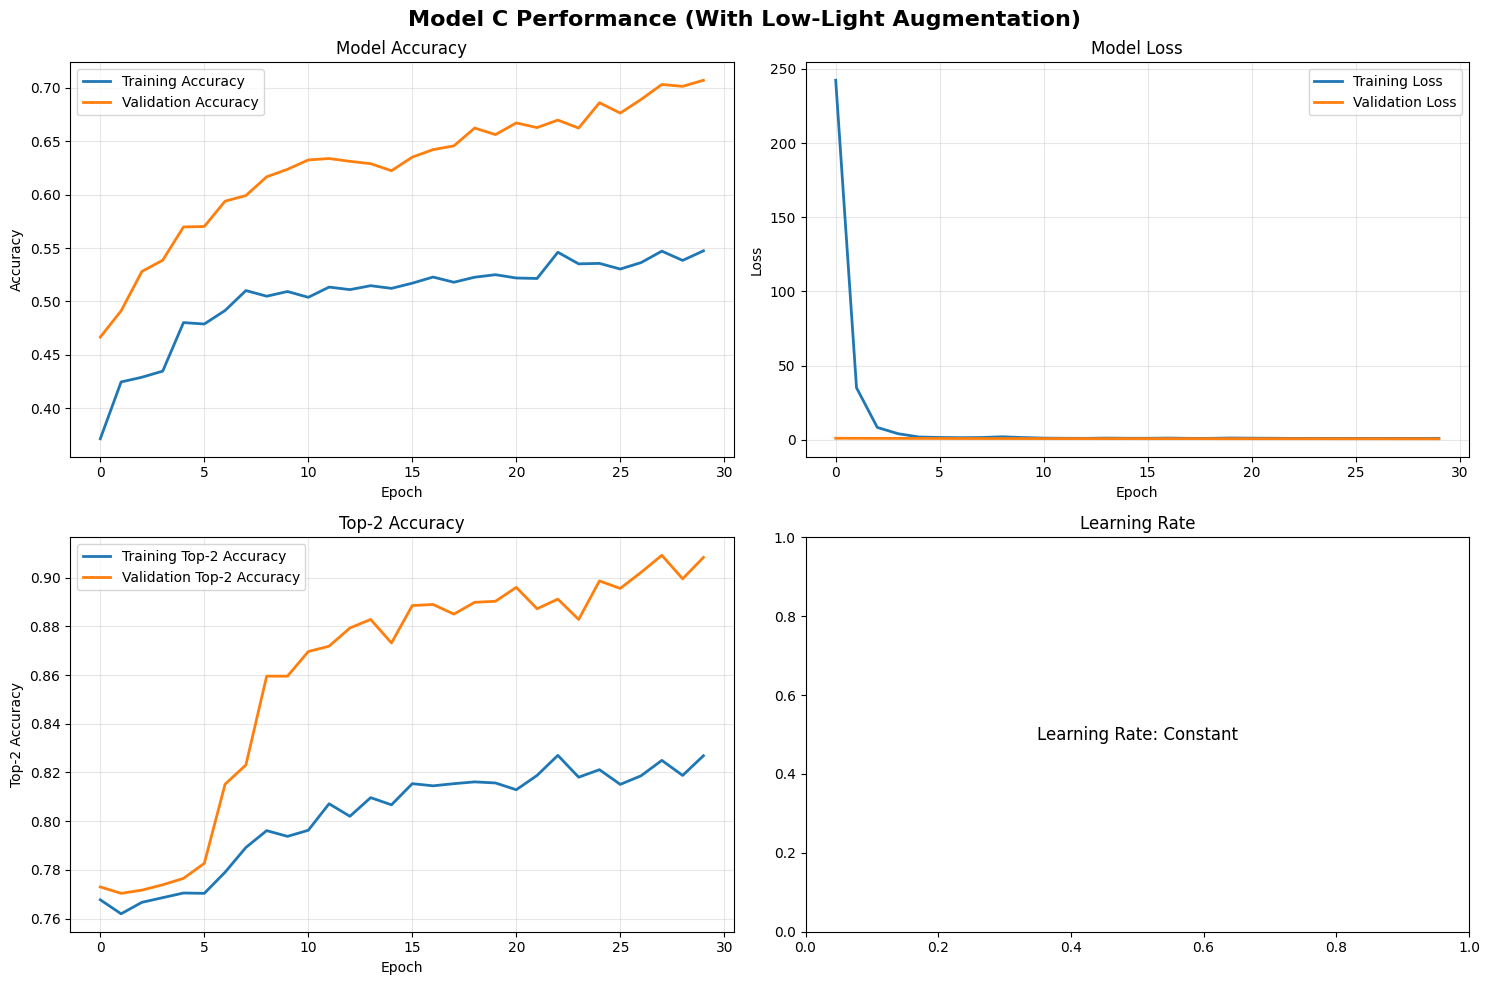

In [ ]:
print("Step 8: Plotting and analyzing Model C results")

# Create plots
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Model C Performance (With Low-Light Augmentation)', fontsize=16, fontweight='bold')

# Accuracy plot
axes[0, 0].plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
axes[0, 0].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[0, 0].set_title('Model Accuracy')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Loss plot
axes[0, 1].plot(history.history['loss'], label='Training Loss', linewidth=2)
axes[0, 1].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0, 1].set_title('Model Loss')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Top-2 Accuracy plot
axes[1, 0].plot(history.history['top_2_accuracy'], label='Training Top-2 Accuracy', linewidth=2)
axes[1, 0].plot(history.history['val_top_2_accuracy'], label='Validation Top-2 Accuracy', linewidth=2)
axes[1, 0].set_title('Top-2 Accuracy')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Top-2 Accuracy')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Learning rate plot
if 'lr' in history.history:
    axes[1, 1].plot(history.history['lr'], label='Learning Rate', linewidth=2, color='red')
    axes[1, 1].set_title('Learning Rate Schedule')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Learning Rate')
    axes[1, 1].set_yscale('log')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
else:
    axes[1, 1].text(0.5, 0.5, 'Learning Rate: Constant',
                   horizontalalignment='center', verticalalignment='center',
                   transform=axes[1, 1].transAxes, fontsize=12)
    axes[1, 1].set_title('Learning Rate')

plt.tight_layout()
plt.savefig('ModelC_performance.png', dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
print("Step 9: Final model C evaluation")

# Calculate final metrics
final_train_accuracy = history.history['accuracy'][-1]
final_val_accuracy = history.history['val_accuracy'][-1]
final_train_loss = history.history['loss'][-1]
final_val_loss = history.history['val_loss'][-1]

print("\n" + "="*60)
print("MODEL C FINAL RESULTS")
print("="*60)
print(f"Final Training Accuracy: {final_train_accuracy:.4f}")
print(f"Final Validation Accuracy: {final_val_accuracy:.4f}")
print(f"Final Training Loss: {final_train_loss:.4f}")
print(f"Final Validation Loss: {final_val_loss:.4f}")
print(f"Training Epochs: {len(history.history['accuracy'])}")
print(f"Best Validation Accuracy: {max(history.history['val_accuracy']):.4f}")
print("="*60)

# Save final results summary
results_summary = {
    'model_type': 'with low-light augmentation',
    'final_training_accuracy': float(final_train_accuracy),
    'final_validation_accuracy': float(final_val_accuracy),
    'final_training_loss': float(final_train_loss),
    'final_validation_loss': float(final_val_loss),
    'best_validation_accuracy': float(max(history.history['val_accuracy'])),
    'total_epochs_trained': len(history.history['accuracy']),
    'dataset_info': {
        'training_samples': train_generator.samples,
        'validation_samples': validation_generator.samples,
        'class_names': CONFIG["class_names"]
    }
}

with open('modelC_results_summary.json', 'w') as f:
    json.dump(results_summary, f, indent=4)

Step 9: Final model C evaluation

MODEL C FINAL RESULTS
Final Training Accuracy: 0.5474
Final Validation Accuracy: 0.7072
Final Training Loss: 0.9768
Final Validation Loss: 0.6836
Training Epochs: 30
Best Validation Accuracy: 0.7072
